<img src="../../_images/logos/Scikit_learn.png" width="200px">

# Scikit-learn - Topic 4 - Cross Validation Search (GridSearchCV) and Hyperparameter Optimisation Regression - One algorithm

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Learn and use GridSearchCV for Hyperparameter Optimisation

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

We will install scikit-learn, xgboost, feature-engine and yellow brick to run our exercises.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Scikit-learn - Topic 4 - Cross Validation Search (GridSearchCV) and Hyperparameter Optimisation

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

Good job! You fitted multiple pipelines, considering different algorithms separately for regression and classification tasks. However, how do you know which was better for a given ML task? 
* Imagine for the classification task on the iris dataset, you fitted three individual pipelines, evaluated each separately, and concluded a given algorithm was better. That is fair enough, but you want a more effective way to assess multiple algorithms.
* However, you also fitted the models with the default hyperparameters. What if, for a given algorithm, I could fit multiple models using different hyperparameters and find a model with even better performance?

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%208-%20Challenge.png"> 

Let's learn how to use GridSearchCV and do Hyperparameter Optimisation using multiple algorithms. 
* This is the heart of conventional ML. We will split this topic into two parts: 
  * In the next three notebooks, we will show how to conduct hyperparameter optimisation using one algorithm (for Regression, Binary Classification and Multiclass Classification).
  * Then we will cover how to do hyperparameter optimisation using multiple algorithms at once.

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">  

### Hyperparameter Optimisation with one algorithm

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

In this section, we will select a given algorithm and fine-tune it, by defining a set of hyperparameters. 
* A set of models will be fitted for each possible hyperparameter combination based on the cross-validation parameter. For example, if the developer sets cross-validation to 5, it will fit five models for a given hyperparameter combination. 
* These five models are scored against a performance metric (i.e., if it is regression, it could be the R2 score), and average performance is computed. This average is the cross-validated performance for a given configuration of hyperparameters. 
* This process is repeated then for every combination of hyperparameters. 



<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png">  

Let's quickly recap how we use the data for fitting supervised models.
* The training subset of the data is used to fit or train the model.
* A subset of the training set is known as the validation set. This is used during fitting to compare one model against another and when choosing or tuning hyperparameters. 
* The final subset of data used to test the model is known as the test set. This assesses the final model's performance, and it must be new data to the model to give an unbiased result. The test set closely replicates what the deployed model will see in real-time usage. 


<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Result.png
">   

When we do Hyperparameter Optimisation, a part of the train set is automatically subset as a validation set, and the model is fitted using cross-validation. 

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

How can I do that in Scikit-learn? 
* We use a function called **GridSearchCV**, which fits multiple models looping through a hyperparameter list over each model. 
* Note: CV here means cross-validation. It uses cross-validation to  compare different algorithm and hyperparameter combinations. In the end, we can select the best parameters from the listed hyperparameters that achieve better performance.
* Ultimately, it helps automate the process of finding the best combination of hyperparameters for a given algorithm in a given dataset. The documentation is found [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

We will split this section showing use cases for GridSearchCV on Regression, Binary Classification, Multiclass classification task
* When using GridSearchCV, the difference between these ML tasks relies on the scoring parameters, which tell which performance metric should be used to select the best model.

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">  

#### Regression

<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Challenge%20test.png">

 We are going to consider a similar workflow we studied earlier:
* Split the data
* Define the pipeline 
* Fit the pipeline
* Evaluate the pipeline

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png">

The differences now are:
* we decide on a list of hyperparameters to optimise our model while fitting it
* we need a performance metric to decide which model is the best for cross-validating the models.

We will use the California Housing dataset from sklearn. It has house price records and characteristics, like the average occupancy and house age.

In [6]:
from sklearn.datasets import fetch_openml
data = fetch_openml(data_id=44977, as_frame=True)
df_reg = pd.DataFrame(data.data,columns=data.feature_names)
df_reg['price'] = pd.Series(data.target)

df_reg = df_reg.sample(frac=0.5, random_state=101)

print(df_reg.shape)
df_reg.head()

(10320, 9)


,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,price
16086,-122.49,37.73,36,1821,292,742,298,5.6204,406200.0
8816,-118.32,33.75,37,1080,135,366,142,11.6677,500001.0
7175,-118.19,34.05,47,1273,264,1193,260,2.4375,122900.0
16714,-120.68,35.51,17,1701,298,941,293,4.3218,209100.0
14491,-117.24,32.85,22,3479,448,1252,440,10.0707,500001.0


We split the data into train and test sets.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(
                                    df_reg.drop(['price'],axis=1),
                                    df_reg['price'],
                                    test_size=0.2,
                                    random_state=101
                                    )

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:", X_test.shape, y_test.shape)

* Train set: (8256, 8) (8256,) 
* Test set: (2064, 8) (2064,)


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

Similar to previous examples, we set the pipeline with three steps; feature scaling, feature selection and modelling. 
* For the purpose of learning hyperparameter optimisation, we just set the algorithm used to RandomForestRegressor. However, we would like to encourage you to try additional algorithms. There are example algorithms commented out that you can try.

In [8]:
from sklearn.pipeline import Pipeline

### Feat Scaling
from sklearn.preprocessing import StandardScaler

### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithms 
#from sklearn.ensemble import AdaBoostRegressor
#from sklearn.linear_model import LinearRegression
#from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
#from sklearn.tree import DecisionTreeRegressor

def pipeline_adaboost_reg():
  pipeline = Pipeline([
      ( "feat_scaling",StandardScaler() ),
      ( "feat_selection",SelectFromModel(RandomForestRegressor(random_state=101)) ),
      ( "model", RandomForestRegressor(random_state=101)),

    ])

  return pipeline

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

We should parse the **algorithm's hyperparameters**, in a dictionary, with support from its documentation, which is found [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
* Since we are fitting a pipeline, that contains a set of steps, you should state in your hyperparameter list to which step your hyperparameter belongs. In our case, we named the modelling step `"model"`, so we add the suffix `"model__" `before the hyperparameter name.
* For this example, we picked only one hyperparameter: n_estimators. For n_estimator, we parse in a list with 10 and 20 (the default value is 50, but for faster computation, in this teaching example, we set it to 10 and 20)
* It will take time and practical experience to make sense of which hyperparameters are more useful for each algorithm and what are the typical ranges to consider when listing hyperparameter's values.

In [9]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html  # documentation is here
param_grid = {"model__n_estimators":[10,20],
              }

param_grid

{'model__n_estimators': [10, 20]}

We import GridSearchCV. Its documentation is found [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). We parse
*  `estimator` as the pipeline, and `param_grid` as the dictionary we stated above. 
* `cv` sets the number of cross-validation you want to try for each selected set of hyperparameters. It uses k-fold cross-validation, where we subdivide the whole dataset into multiple randomly chosen data sets known as k-fold cross-validation where k refers to the number of data sets.  
* `n_jobs`, according to the documentation, is the number of jobs to run in parallel. -1 means using all processors, whereas -2 uses all but one.
* `scoring` is the evaluation metric that you want to use.  That will depend on the ML task you are considering. In this case, it is regression, so we set the R2 score as the metric. Other options would include: `'neg_mean_absolute_error'`, `'neg_mean_squared_error'`
* `verbose`, according to the documentation, controls the verbosity: the higher, the more messages. As this is a teaching example, we set it as 3, so you get more information returned about the process.

<img width="3%" height="3%" align="top"  src=" https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Result.png"> 

We create an object (called the grid) that contains a GridSearchCV using the above parameters. Next, we fit this object to the train set (features and target).

* That will fit multiple RandomForestRegressor models. Considering cv=2 and the hyperparameters we listed above, it will train two models. It trains two models since we have two possible combinations of hyperparameters.
* For each model, we use 2-fold cross-validation, since cv=2. Therefore, each model will be fitted twice.
* In total, this operation will fit four models, two models where each model is fitted two times, due to 2-fold cross-validation.
* Note, the two scores for `model__n_estimators=10` (the first two test_scores) are 0.48 and 0.489. The mean is 0.4845. We will highlight this mean to you when computing the cross-validation results for this hyperparameter combination in upcoming cells.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> 

Remember, the validation set is automatically defined using GridSearchCV. You parse the training set, and it will subset the validation set as a part of the training set.

In [10]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=pipeline_adaboost_reg(),
                    param_grid=param_grid,
                    cv=2,
                    n_jobs=-2,
                    verbose=3,  # for learning, we set 3 to print the score from every cross-validation
                    scoring='r2')


grid.fit(X_train,y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_estimators': [10, 20]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

The results of all models and their respective cross-validations are stored in the attribute `.cv_results`
* When you access this attribute, you will see it is a dictionary and when displayed as is, is not very informative.

In [11]:
grid.cv_results_

{'mean_fit_time': array([2.21710455, 2.33218002]),
 'std_fit_time': array([0.01136029, 0.01499104]),
 'mean_score_time': array([0.02911472, 0.03657055]),
 'std_score_time': array([0.00013995, 0.00052214]),
 'param_model__n_estimators': masked_array(data=[10, 20],
              mask=[False, False],
        fill_value=999999),
 'params': [{'model__n_estimators': 10}, {'model__n_estimators': 20}],
 'split0_test_score': array([0.54585948, 0.55945657]),
 'split1_test_score': array([0.75056497, 0.76247578]),
 'mean_test_score': array([0.64821223, 0.66096618]),
 'std_test_score': array([0.10235275, 0.1015096 ]),
 'rank_test_score': array([2, 1], dtype=int32)}

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

One way to make it more informative is to parse it to a DataFrame, sort the values by 'mean_test_score', filter 'parameters' and 'mean_test_score' columns and convert it to an array, using .values
* In the end, you print a simplified ordered list showing the results for optimising a model with multiple hyperparameter combinations.
  * For example, we see the best hyperparameter configuration is `n_estimators 20`, which gave an R2 score of 0.502
  * Note the second hyperparameter combination: `model__n_estimators=10`. Previously we commented on its average performance: 0.4845. That is a result of the mean of the 2 cross-validated models for this hyperparameter combination. In this particular example, considering this set of hyperparameter combinations, its performance was worse compared to the other.

In [12]:
(pd.DataFrame(grid.cv_results_)
.sort_values(by='mean_test_score',ascending=False)
.filter(['params','mean_test_score'])
.values
 )

array([[{'model__n_estimators': 20}, 0.6609661790570827],
       [{'model__n_estimators': 10}, 0.6482122275619692]], dtype=object)

Additionally, we can get the best parameters with `.best_params_`

In [13]:
grid.best_params_

{'model__n_estimators': 20}

This is interesting, but we want to have the pipeline with the
highest score, for real-world usage. To get it, use the attribute `.best_estimator_`
* This is the most important aspect of the grid search, where we grab the pipeline, which we will evaluate and potentially use.
* Note, when fitting the pipelines, you saw the score for each cross-validated model for each hyperparameter combination. For the best hyperparameter combination, it takes the best cross-validated model. In this case, it takes the last.
  * `[CV 1/2] END ............model__n_estimators=20;, score=0.495 total time=   0.2s`
  * `[CV 2/2] END ............model__n_estimators=20;, score=0.509 total time=   0.2s`

In [14]:
pipeline = grid.best_estimator_
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaling', ...), ('feat_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",RandomForestR...dom_state=101)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


You can now evaluate the pipeline that you fit using hyperparameter optimisation using the techniques we covered already. We will import the custom function for regression evaluation.

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
import numpy as np

def regression_performance(X_train, y_train, X_test, y_test,pipeline):
	print("Model Evaluation \n")
	print("* Train Set")
	regression_evaluation(X_train,y_train,pipeline)
	print("* Test Set")
	regression_evaluation(X_test,y_test,pipeline)



def regression_evaluation(X,y,pipeline):
  prediction = pipeline.predict(X)
  print('R2 Score:', round(r2_score(y, prediction), 3))  
  print('Mean Absolute Error:', round(mean_absolute_error(y, prediction), 3))  
  print('Mean Squared Error:', round(mean_squared_error(y, prediction), 3))  
  print('Root Mean Squared Error:', round(np.sqrt(mean_squared_error(y, prediction)), 3))
  print("\n")

  

def regression_evaluation_plots(X_train, y_train, X_test, y_test,pipeline, alpha_scatter=0.5):
  pred_train = pipeline.predict(X_train)
  pred_test = pipeline.predict(X_test)


  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
  sns.scatterplot(x=y_train , y=pred_train, alpha=alpha_scatter, ax=axes[0])
  sns.lineplot(x=y_train , y=y_train, color='red', ax=axes[0])
  axes[0].set_xlabel("Actual")
  axes[0].set_ylabel("Predictions")
  axes[0].set_title("Train Set")

  sns.scatterplot(x=y_test , y=pred_test, alpha=alpha_scatter, ax=axes[1])
  sns.lineplot(x=y_test , y=y_test, color='red', ax=axes[1])
  axes[1].set_xlabel("Actual")
  axes[1].set_ylabel("Predictions")
  axes[1].set_title("Test Set")
  plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

Next, we parse the train set, test set and our pipeline to the function
* Note the performance on the train test is good (0.922). The test set is not so good (0.541). However, these values are mismatched, which may indicate overfitting.
* We may have to consider additional values for the hyperparameters or even consider other hyperparameters. Or maybe we need more data so the algorithm can find the patterns and generalise on unseen data.
* Or maybe this algorithm is not the best for this dataset. But don't worry, soon we will discover an approach to train multiple algorithms at once.

Model Evaluation 

* Train Set
R2 Score: 0.968
Mean Absolute Error: 13049.439
Mean Squared Error: 425691858.148
Root Mean Squared Error: 20632.301


* Test Set
R2 Score: 0.803
Mean Absolute Error: 33422.535
Mean Squared Error: 2567578835.898
Root Mean Squared Error: 50671.282




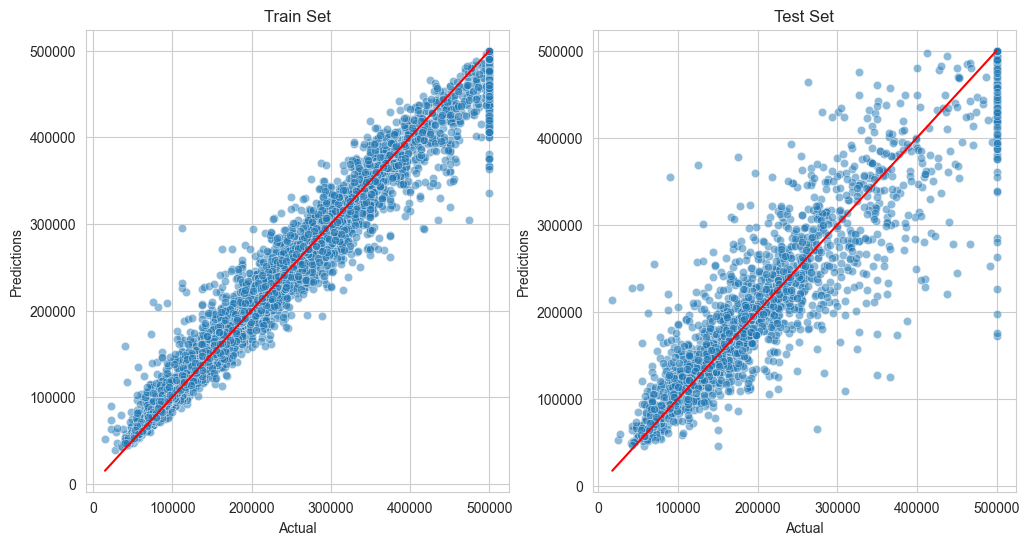

In [16]:
regression_performance(X_train, y_train, X_test, y_test,pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, 
                            pipeline, alpha_scatter=0.5)